# Ice Dynamics I: Lecture Figures

In [1]:
# ---- Setup: imports and physical constants ----
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({
    'font.size': 12, 'axes.labelsize': 14, 'axes.titlesize': 14,
    'legend.fontsize': 11, 'xtick.labelsize': 11, 'ytick.labelsize': 11,
    'figure.dpi': 150, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'text.usetex': False, 'font.family': 'serif',
})

figdir = Path('figures')
figdir.mkdir(exist_ok=True)
rho_i = 917.0; g = 9.81; sec_per_yr = 365.25 * 24 * 3600
print('Setup complete.')

Setup complete.


## Figure 0: Parallel Slab Schematic

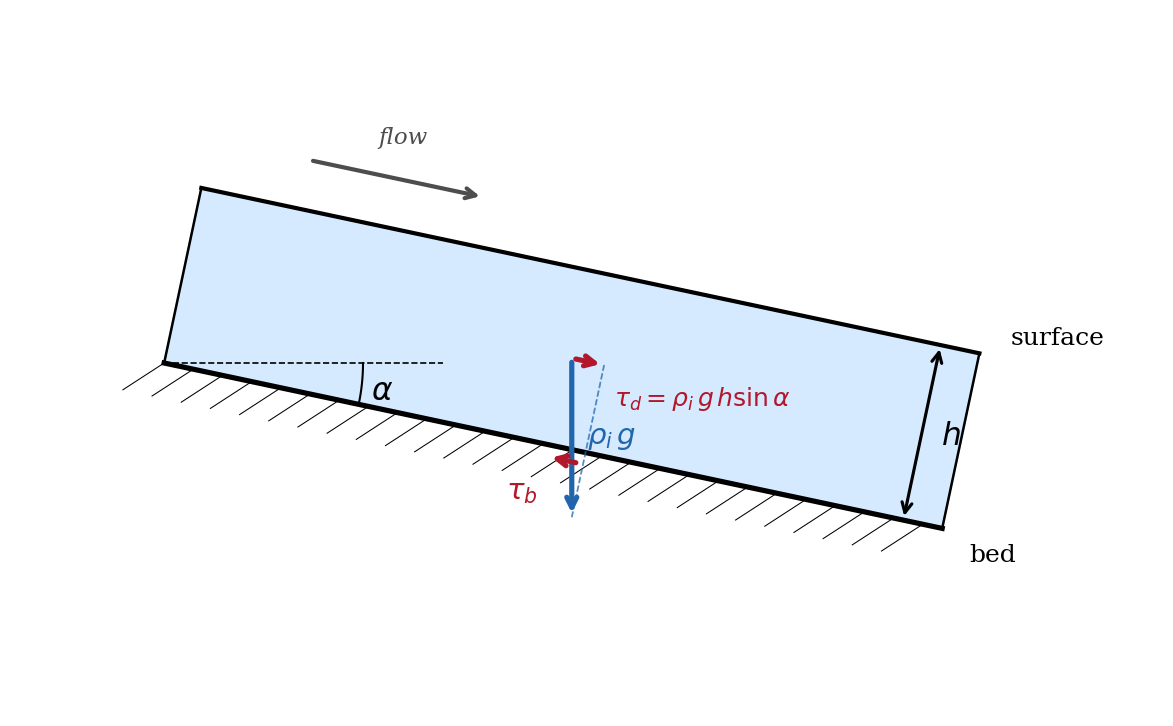

In [2]:
# ---- Fig0: parallel slab schematic ----
fig, ax = plt.subplots(figsize=(9, 5))
ax.set_aspect('equal'); ax.axis('off')

alpha_deg = 12; alpha = np.radians(alpha_deg)
slab_len = 8.0; h = 1.8
ca, sa = np.cos(alpha), np.sin(alpha)

def rot(x, z):
    return ca*x + sa*z, -sa*x + ca*z

# Ice slab
cx, cz = rot(np.array([0,slab_len,slab_len,0]), np.array([0,0,h,h]))
ax.fill(cx, cz, color='#b3d9ff', alpha=0.55, zorder=1)
for zv, lw in [(0, 2.5), (h, 2.0)]:
    xp, zp = rot(np.array([0,slab_len]), np.array([zv,zv]))
    ax.plot(xp, zp, 'k-', lw=lw, zorder=2)
for xv in [0, slab_len]:
    xp, zp = rot(np.array([xv,xv]), np.array([0,h]))
    ax.plot(xp, zp, 'k-', lw=1.2, zorder=2)

# Bedrock hatching
for i in range(int(slab_len*3)+3):
    xs = i*0.3
    if xs > slab_len: break
    x0,z0 = rot(xs, 0); x1,z1 = rot(xs-0.35, -0.35)
    ax.plot([x0,x1],[z0,z1],'k-',lw=0.5,zorder=0)

# Labels
xp,zp = rot(slab_len+0.3, -0.1); ax.text(xp,zp,'bed',fontsize=12,ha='left',va='top')
xp,zp = rot(slab_len+0.3, h+0.1); ax.text(xp,zp,'surface',fontsize=12,ha='left',va='bottom')
x0a,z0a = rot(slab_len-0.4, 0); x1a,z1a = rot(slab_len-0.4, h)
ax.annotate('',xy=(x1a,z1a),xytext=(x0a,z0a),arrowprops=dict(arrowstyle='<->',lw=1.5))
xh,zh = rot(slab_len-0.2, h/2); ax.text(xh,zh,'$h$',fontsize=15,ha='left',va='center',fontweight='bold')

# Angle alpha
x0_h,z0_h = rot(0,0)
ax.plot([x0_h, x0_h+2.8],[z0_h, z0_h],'k--',lw=0.8)
theta_arc = np.linspace(0, -alpha, 40)
ax.plot(x0_h+2.0*np.cos(theta_arc), z0_h+2.0*np.sin(theta_arc), 'k-', lw=1)
ax.text(x0_h+2.2*np.cos(-alpha/2), z0_h+2.2*np.sin(-alpha/2)+0.1,
        r'$\alpha$', fontsize=15, ha='center', va='top')

# Gravity vector (straight down from center of slab)
gcx, gcz = rot(slab_len/2, h/2)
grav_len = 1.6
ax.annotate('', xy=(gcx, gcz - grav_len), xytext=(gcx, gcz),
            arrowprops=dict(arrowstyle='->', color='#2166ac', lw=2.5))
ax.text(gcx + 0.15, gcz - 0.8, r'$\rho_i\,g$', fontsize=14, ha='left', va='center',
        color='#2166ac', fontweight='bold')

# Driving force vector (slope-parallel component of gravity, downslope from same point)
# The downslope component in plot coords: direction is (ca, -sa), magnitude is grav_len * sin(alpha)
drv_len = grav_len * sa  # slope-parallel component: g * sin(alpha)
drv_dx = drv_len * ca   # plot-x component of downslope direction
drv_dz = -drv_len * sa  # plot-y component of downslope direction
ax.annotate('', xy=(gcx + drv_dx, gcz + drv_dz), xytext=(gcx, gcz),
            arrowprops=dict(arrowstyle='->', color='#b2182b', lw=2.5))
ax.text(gcx + drv_dx + 0.1, gcz + drv_dz - 0.2,
        r'$\tau_d = \rho_i\,g\,h\sin\alpha$', fontsize=12,
        ha='left', va='top', color='#b2182b', fontweight='bold')

# Dashed lines showing the decomposition (right-angle projection)
# From gravity tip to driving force tip (perpendicular to slope)
grav_tip_x, grav_tip_y = gcx, gcz - grav_len
drv_tip_x, drv_tip_y = gcx + drv_dx, gcz + drv_dz
ax.plot([grav_tip_x, drv_tip_x], [grav_tip_y, drv_tip_y],
        '--', color='#2166ac', lw=0.8, alpha=0.5)
ax.plot([drv_tip_x, gcx], [drv_tip_y, gcz - grav_len],
        '--', color='#2166ac', lw=0.8, alpha=0.5)

# Basal shear stress (opposing motion, upslope at the bed, same length as driving stress)
tau_bx0, tau_bz0 = rot(slab_len/2 + 0.3, -0.12)  # start slightly below bed at slab center
tau_bx1, tau_bz1 = rot(slab_len/2 + 0.3 - drv_len, -0.12)  # upslope, same length as tau_d
ax.annotate('', xy=(tau_bx1, tau_bz1), xytext=(tau_bx0, tau_bz0),
            arrowprops=dict(arrowstyle='->', color='#b2182b', lw=2.5))
ax.text(tau_bx1 - 0.1, tau_bz1 - 0.2,
        r'$\tau_b$', fontsize=14, ha='right', va='top', color='#b2182b', fontweight='bold')

# Flow direction
fx0,fz0 = rot(1.0,h+0.5); fx1,fz1 = rot(2.8,h+0.5)
ax.annotate('',xy=(fx1,fz1),xytext=(fx0,fz0),arrowprops=dict(arrowstyle='->',color='0.3',lw=2))
ftx,ftz = rot(1.9,h+0.8); ax.text(ftx,ftz,'flow',fontsize=11,ha='center',va='bottom',color='0.3',style='italic')

ax.set_xlim(-1.5, 10); ax.set_ylim(-3.5, 3.5)
fig.tight_layout()
fig.savefig(figdir/'fig00_parallel_slab_schematic.pdf')
fig.savefig(figdir/'fig00_parallel_slab_schematic.png')
plt.show()

## Figure 1: Velocity Profiles for Simple Shear

<>:6: SyntaxWarning: invalid escape sequence '\,'
<>:6: SyntaxWarning: invalid escape sequence '\,'
<>:6: SyntaxWarning: invalid escape sequence '\,'
<>:6: SyntaxWarning: invalid escape sequence '\,'
/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_32094/3093802472.py:6: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$u \, / \, u_s$'); ax.set_ylabel('$(z - b) \, / \, h$')
/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_32094/3093802472.py:6: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$u \, / \, u_s$'); ax.set_ylabel('$(z - b) \, / \, h$')


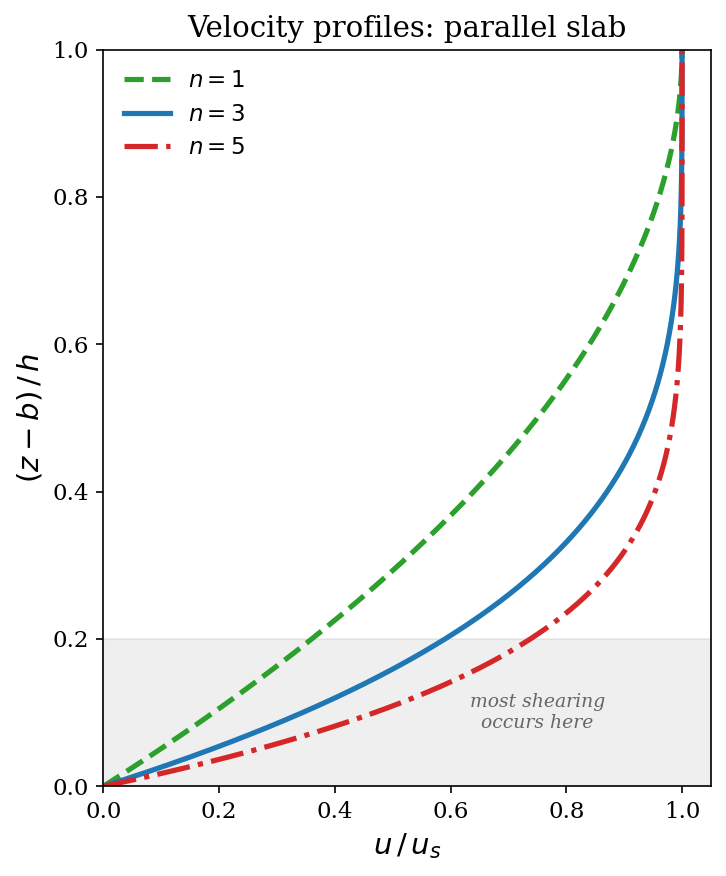

In [3]:
# ---- Fig1: normalized velocity profiles for different n ----
fig, ax = plt.subplots(figsize=(5, 6))
zhat = np.linspace(0, 1, 500)
for n_val, color, ls in zip([1,3,5], ['#2ca02c','#1f77b4','#d62728'], ['--','-','-.']):
    ax.plot(1-(1-zhat)**(n_val+1), zhat, color=color, ls=ls, lw=2.5, label=f'$n = {n_val}$')
ax.set_xlabel('$u \, / \, u_s$'); ax.set_ylabel('$(z - b) \, / \, h$')
ax.set_xlim(0,1.05); ax.set_ylim(0,1)
ax.legend(loc='upper left', frameon=False)
ax.set_title('Velocity profiles: parallel slab')
ax.axhspan(0,0.2,color='gray',alpha=0.12)
ax.text(0.75,0.10,'most shearing\noccurs here',fontsize=9,ha='center',va='center',color='0.4',style='italic')
fig.tight_layout()
fig.savefig(figdir/'fig01_velocity_profiles.pdf')
fig.savefig(figdir/'fig01_velocity_profiles.png')
plt.show()

## Figure 2: Vialov Profiles for Different $n$

<>:9: SyntaxWarning: invalid escape sequence '\,'
<>:9: SyntaxWarning: invalid escape sequence '\,'
<>:9: SyntaxWarning: invalid escape sequence '\,'
<>:9: SyntaxWarning: invalid escape sequence '\,'
/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_32094/2091079010.py:9: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$x \, / \, L$'); ax.set_ylabel('$h \, / \, h_0$')
/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_32094/2091079010.py:9: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$x \, / \, L$'); ax.set_ylabel('$h \, / \, h_0$')


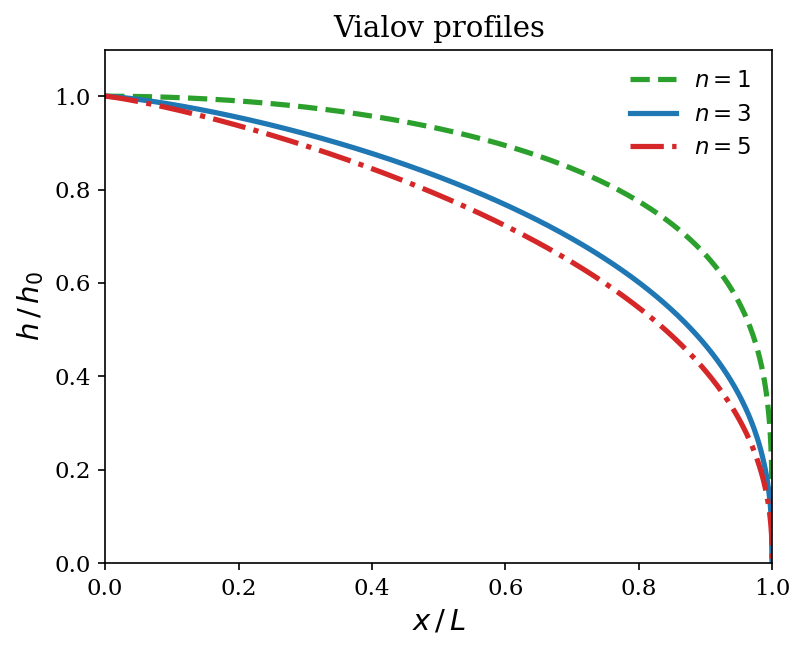

In [4]:
# ---- Fig2: normalized Vialov profiles for different n ----
def vialov_profile(x_norm, n):
    return np.maximum(1 - x_norm**((n+1)/n), 0)**(n/(2*(n+1)))

fig, ax = plt.subplots(figsize=(7, 4.5))
x_norm = np.linspace(0, 1, 1000)
for n_val, color, ls in zip([1,3,5], ['#2ca02c','#1f77b4','#d62728'], ['--','-','-.']):
    ax.plot(x_norm, vialov_profile(x_norm, n_val), color=color, ls=ls, lw=2.5, label=f'$n = {n_val}$')
ax.set_xlabel('$x \, / \, L$'); ax.set_ylabel('$h \, / \, h_0$')
ax.set_xlim(0,1); ax.set_ylim(0,1.1)
ax.legend(loc='upper right', frameon=False)
ax.set_title('Vialov profiles'); ax.set_aspect(0.7)
fig.tight_layout()
fig.savefig(figdir/'fig02_vialov_profiles_n.pdf')
fig.savefig(figdir/'fig02_vialov_profiles_n.png')
plt.show()

## Figure 3: Vialov Profile Insensitivity to Accumulation Rate

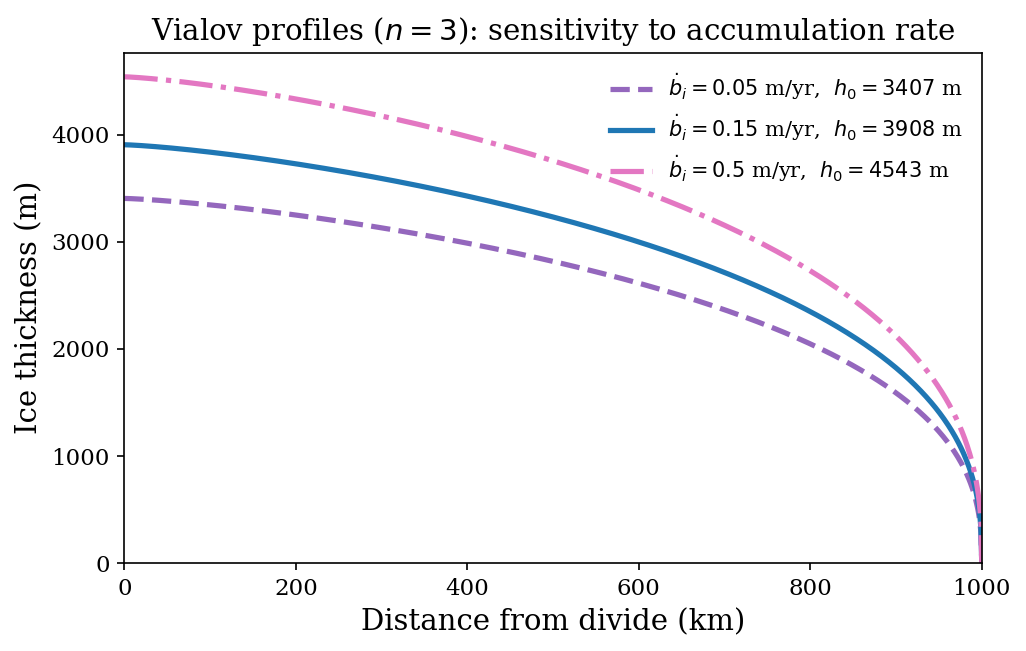

In [5]:
# ---- Fig3: Vialov profiles varying bdot (insensitivity) ----
def vialov_h0(bdot_i, A, L, n):
    return (2**(n-1)*(n+2)*bdot_i / (A*(rho_i*g)**n))**(1/(2*n+2)) * L**((n+1)/(2*n+2))

fig, ax = plt.subplots(figsize=(7, 4.5))
n=3; A=2.4e-24; L=1000e3
x = np.linspace(0,L,1000); x_norm = x/L
for bdot_yr,color,ls in zip([0.05,0.15,0.50],['#9467bd','#1f77b4','#e377c2'],['--','-','-.']):
    bdot = bdot_yr/sec_per_yr; h0 = vialov_h0(bdot,A,L,n)
    ax.plot(x/1e3, h0*vialov_profile(x_norm,n), color=color, ls=ls, lw=2.5,
            label=f'$\\dot{{b}}_i = {bdot_yr}$ m/yr,  $h_0 = {h0:.0f}$ m')
ax.set_xlabel('Distance from divide (km)'); ax.set_ylabel('Ice thickness (m)')
ax.set_xlim(0,L/1e3); ax.set_ylim(0,None)
ax.legend(loc='upper right',frameon=False,fontsize=10)
ax.set_title(f'Vialov profiles ($n = {n}$): sensitivity to accumulation rate')
fig.tight_layout()
fig.savefig(figdir/'fig03_vialov_insensitivity.pdf')
fig.savefig(figdir/'fig03_vialov_insensitivity.png')
plt.show()

## Figure 4: Perfectly Plastic vs. Vialov Profile

<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
<>:7: SyntaxWarning: invalid escape sequence '\,'
/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_32094/1394213666.py:7: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$x \, / \, L$'); ax.set_ylabel('$h \, / \, h_0$')
/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_32094/1394213666.py:7: SyntaxWarning: invalid escape sequence '\,'
  ax.set_xlabel('$x \, / \, L$'); ax.set_ylabel('$h \, / \, h_0$')


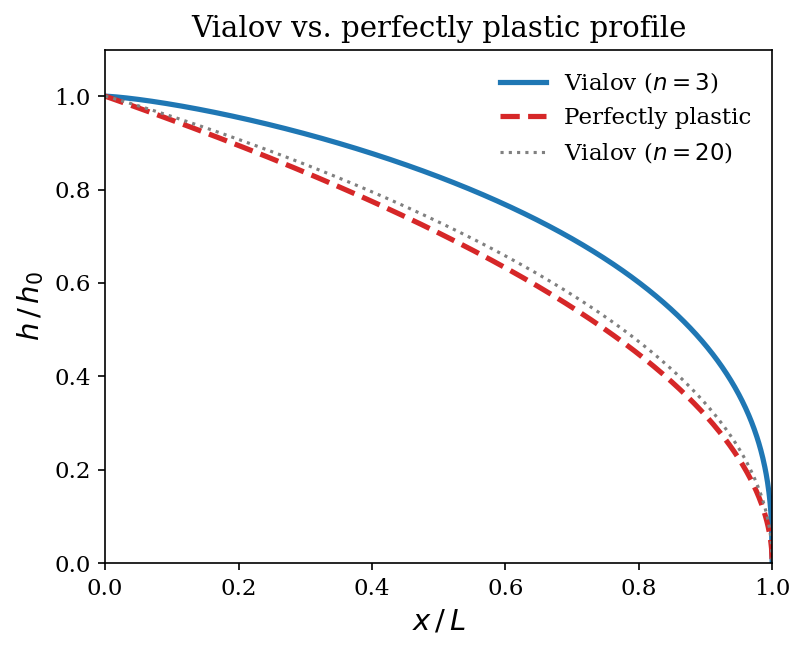

In [6]:
# ---- Fig4: plastic vs Vialov (normalized) ----
fig, ax = plt.subplots(figsize=(7, 4.5))
x_norm = np.linspace(0, 1, 1000)
ax.plot(x_norm, vialov_profile(x_norm,3), '-', color='#1f77b4', lw=2.5, label='Vialov ($n = 3$)')
ax.plot(x_norm, np.sqrt(np.maximum(1-x_norm,0)), '--', color='#d62728', lw=2.5, label='Perfectly plastic')
ax.plot(x_norm, vialov_profile(x_norm,20), ':', color='0.5', lw=1.5, label='Vialov ($n = 20$)')
ax.set_xlabel('$x \, / \, L$'); ax.set_ylabel('$h \, / \, h_0$')
ax.set_xlim(0,1); ax.set_ylim(0,1.1)
ax.legend(loc='upper right',frameon=False)
ax.set_title('Vialov vs. perfectly plastic profile'); ax.set_aspect(0.7)
fig.tight_layout()
fig.savefig(figdir/'fig04_plastic_vs_vialov.pdf')
fig.savefig(figdir/'fig04_plastic_vs_vialov.png')
plt.show()

## Figure 5: Observed vs. Predicted Ice Sheet Profile

Normalized East Antarctic thickness profiles from BedMachine, compared with the Vialov ($n = 3$) and perfectly plastic predictions.

/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_32047/1908583785.py:53: RuntimeWarning: All-NaN slice encountered
  h_med = np.nanmedian(h_resampled, axis=0)
/Users/minchew/opt/anaconda3/envs/python2025/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


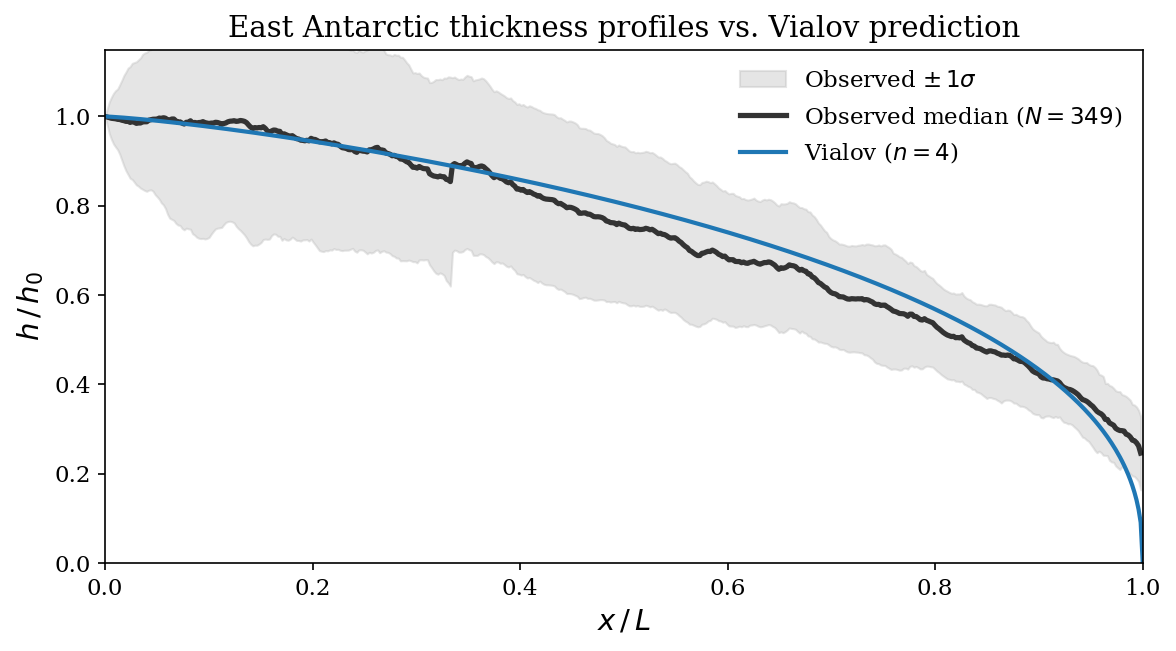

349 profiles, fitted with n = 4


In [8]:
# ---- Fig5: observed vs predicted East Antarctic transect ----
import h5py
from scipy.optimize import minimize_scalar

profiles_path = '/Users/minchew/Documents/MITteaching/glacier_dynamics/2026/lecture_notes/latex/dynamics_fundamentals_1/profiles/east_antarctica_profiles.h5'
with h5py.File(profiles_path, 'r') as f:
    x_norm_obs = f['x_norm'][:]
    h_norm_all = f['h_norm'][:]
    lengths = f['profile_length_m'][:]
    gl_x = f['grounding_line_x_norm'][:]

n_profiles = h_norm_all.shape[0]

# ---- Fit Vialov L for each profile at n=4 ----
def vialov_h(x_phys, L, n):
    xi = np.clip(x_phys / L, 0, 1)
    p = (n + 1) / n
    q = n / (2 * (n + 1))
    return np.maximum(1 - xi**p, 0)**q

def fit_L(x_phys, h_obs, n):
    x_max = x_phys[-1]
    def cost(L):
        return np.mean((h_obs - vialov_h(x_phys, L, n))**2)
    res = minimize_scalar(cost, bounds=(x_max * 0.8, x_max * 3.0),
                          method='bounded')
    return res.x

n_fit = 4
fitted_L = np.zeros(n_profiles)
for i in range(n_profiles):
    gl_idx = min(np.searchsorted(x_norm_obs, gl_x[i]), len(x_norm_obs) - 1)
    x_phys = x_norm_obs[:gl_idx+1] * lengths[i]
    h_obs = h_norm_all[i, :gl_idx+1]
    fitted_L[i] = fit_L(x_phys, h_obs, n_fit)

# Re-normalize each profile by fitted L
n_resamp = 500
xi_fit = np.linspace(0, 1, n_resamp)
h_resampled = np.full((n_profiles, n_resamp), np.nan)

for i in range(n_profiles):
    gl_idx = min(np.searchsorted(x_norm_obs, gl_x[i]), len(x_norm_obs) - 1)
    x_phys = x_norm_obs[:gl_idx+1] * lengths[i]
    h_obs = h_norm_all[i, :gl_idx+1]
    x_fitted = x_phys / fitted_L[i]
    valid = x_fitted <= 1.0
    if valid.sum() > 10:
        h_resampled[i, :] = np.interp(xi_fit, x_fitted[valid],
                                       h_obs[valid], right=np.nan)

# Statistics
h_med = np.nanmedian(h_resampled, axis=0)
h_std = np.nanstd(h_resampled, axis=0)
n_valid = np.sum(np.isfinite(h_resampled), axis=0)
enough = n_valid >= 10

# ---- Figure ----
fig, ax = plt.subplots(figsize=(8, 4.5))

ax.fill_between(xi_fit[enough],
                (h_med - h_std)[enough], (h_med + h_std)[enough],
                color='0.75', alpha=0.4, label=r'Observed $\pm\,1\sigma$')
ax.plot(xi_fit[enough], h_med[enough], '-', color='0.2', lw=2.5,
        label=f'Observed median ($N = {n_profiles}$)')

h_v = vialov_profile(xi_fit, n_fit)
ax.plot(xi_fit, h_v, '-', color='#1f77b4', lw=2,
        label=f'Vialov ($n = {n_fit}$)')

ax.set_xlabel(r'$x \, / \, L$')
ax.set_ylabel(r'$h \, / \, h_0$')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', frameon=False)
ax.set_title('East Antarctic thickness profiles vs. Vialov prediction')

fig.tight_layout()
fig.savefig(figdir / 'fig05_observed_vs_predicted.pdf')
fig.savefig(figdir / 'fig05_observed_vs_predicted.png')
plt.show()

print(f'{n_profiles} profiles, fitted with n = {n_fit}')
